In [1]:
import os
hf_home = "/mnt/shared-storage-user/p1-shared/leihaodi/pretrain/hf_cache"
os.environ["HF_HOME"] = hf_home
os.environ["HF_HUB_CACHE"] = f"{hf_home}/hub"
os.environ["HF_DATASETS_CACHE"] = f"{hf_home}/datasets"

os.environ["HF_DATASETS_OFFLINE"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["HF_ALLOW_CODE_EVAL"] = "1"

from datasets import load_dataset
ds = load_dataset('google-research-datasets/mbpp', 'full')


/mnt/shared-storage-user/p1-shared/leihaodi/miniconda3/envs/sglang_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using the latest cached version of the dataset since google-research-datasets/mbpp couldn't be found on the Hugging Face Hub (offline mode is enabled).
Found the latest cached dataset configuration 'full' at /mnt/shared-storage-user/p1-shared/leihaodi/pretrain/hf_cache/datasets/google-research-datasets___mbpp/full/0.0.0/4bb6404fdc6cacfda99d4ac4205087b89d32030c (last modified on Mon Feb 23 18:28:50 2026).


In [3]:
# Cell 1 — 依赖
%matplotlib inline
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def parse_nll_markdown(path: str | Path) -> pd.DataFrame:
    text = Path(path).read_text(encoding="utf-8")
    # 按二级标题切分
    parts = re.split(r"(?m)^##\s+", text.strip())
    rows = []
    for chunk in parts:
        if not chunk.strip():
            continue
        lines = chunk.splitlines()
        dataset = lines[0].strip()  # 标题行：数据集名
        body = "\n".join(lines[1:])
        # 在每个小节前识别 think / no-think
        for m in re.finditer(
            r"(?is)(?:(?:^|\n)\s*(no-think|not-hink|think|No-think|Think|NO-THINK)[^\n]*\n)(.*?)(?=\n\s*(?:no-think|not-hink|think|No-think|Think|NO-THINK)\b|\Z)",
            body,
        ):
            label_raw = m.group(1)
            block = m.group(2)
            lab = label_raw.lower().replace("not-hink", "no-think")
            if "no-think" in lab or lab == "not-hink":
                mode = "no-think"
            elif "think" in lab and "no" not in lab:  # think 但不误伤 no-think
                mode = "think"
            else:
                continue
            m_nats = re.search(
                r"Average token loss / cross-entropy \(nats\)\s*:\s*([0-9.]+)",
                block,
            )
            if not m_nats:
                continue
            nats = float(m_nats.group(1))
            rows.append({"dataset": dataset, "mode": mode, "nats": nats})
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    # 去重：同一 dataset+mode 取最后一次（或改为 first）
    df = df.drop_duplicates(subset=["dataset", "mode"], keep="last")
    return df
# 改成你的文件路径
md_path = "/mnt/shared-storage-user/leihaodi/diffusion/nll-average.md"
df = parse_nll_markdown(md_path)
df

,dataset,mode,nats
0,codealpaca-20k,no-think,0.075374
1,codealpaca-20k,think,0.157169
2,nv-math&code,no-think,0.115372
3,nv-math&code,think,0.160552
4,nv-stem,think,0.224027
5,nv-stem,no-think,0.147560


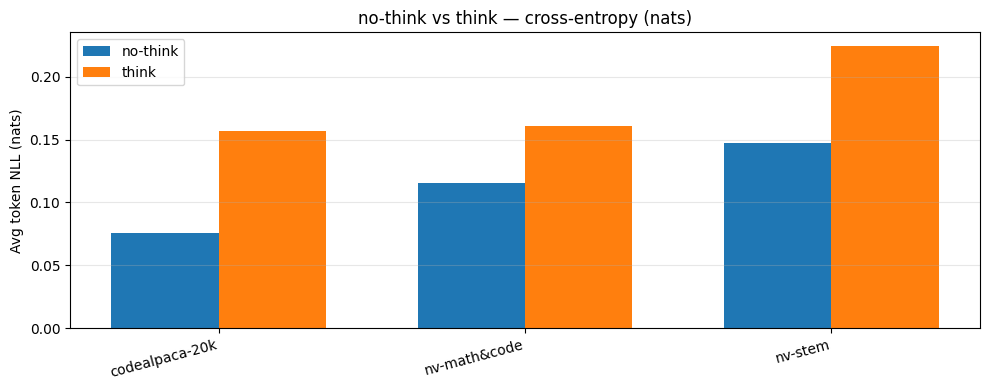

In [4]:
# Cell 3 — 宽表 + 画图
pivot = (
    df.pivot(index="dataset", columns="mode", values="nats")
    .reindex(columns=["no-think", "think"])
)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(pivot.index))
w = 0.35
ax.bar(x - w / 2, pivot["no-think"], w, label="no-think")
ax.bar(x + w / 2, pivot["think"], w, label="think")
ax.set_xticks(x, pivot.index, rotation=15, ha="right")
ax.set_ylabel("Avg token NLL (nats)")
ax.set_title("no-think vs think — cross-entropy (nats)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### pretrain数据读取

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("/mnt/shared-storage-user/cuiganqu/pretrain/final_data").expanduser()
FILE = DATA_DIR / "bucket_0255_rank_027.parquet"

df = pd.read_parquet(FILE, columns=["f", "s"])
df.head()
def analyze_col(series: pd.Series, col_name: str):
    counts = series.value_counts()
    valid_keys = counts[counts >= 10].index
    filtered = series[series.isin(valid_keys)]
    print(f"\n{'='*60}")
    print(f"列 [{col_name}]  过滤后保留 {len(valid_keys)}/{len(counts)} 个 key（计数 >= 10）")
    print(f"保留行数: {len(filtered)} / {len(series)}")

    # Run-length encoding：找出每段连续相同值的区间
    vals = series.values
    # 相邻不同处的边界
    change_mask = np.concatenate(([True], vals[1:] != vals[:-1]))
    starts = np.where(change_mask)[0]
    ends = np.concatenate((starts[1:], [len(vals)]))
    run_keys = vals[starts]
    run_lengths = ends - starts

    # 只保留 valid_keys 中的 run
    mask = pd.Series(run_keys).isin(valid_keys).values
    run_keys_f   = run_keys[mask]
    run_starts_f = starts[mask]
    run_ends_f   = ends[mask] - 1        # inclusive end
    run_lengths_f = run_lengths[mask]

    runs_df = pd.DataFrame({
        "key": run_keys_f,
        "start_row": run_starts_f,
        "end_row": run_ends_f,
        "run_len": run_lengths_f,
    })

    print(f"\n--- 各 key 的连续 run 统计 ---")
    summary = (
        runs_df.groupby("key")["run_len"]
        .agg(run_count="count", run_len_min="min", run_len_max="max", run_len_mean="mean", run_len_sum="sum")
        .sort_values("run_len_sum", ascending=False)
    )
    summary["run_len_mean"] = summary["run_len_mean"].round(1)
    print(summary.to_string())

    # 找出"纯连续大块"：单次 run 长度 >= 1000 的
    big_runs = runs_df[runs_df["run_len"] >= 1000].sort_values("start_row")
    print(f"\n--- 单段连续长度 >= 1000 的区间（共 {len(big_runs)} 段）---")
    if len(big_runs) > 0:
        print(big_runs.to_string(index=False))
    else:
        print("无")

    # 整体交错程度：run 总数 vs key 数
    print(f"\n总 run 数（计数>=10 的 key）: {len(runs_df)}")
    print(f"平均每个 key 被分成多少段: {len(runs_df) / len(valid_keys):.1f}")


ONLY_S = True

analyze_col(df["s"], "s")
if not ONLY_S:
    analyze_col(df["f"], "f")



列 [s]  过滤后保留 6/8 个 key（计数 >= 10）
保留行数: 90509 / 94000

--- 各 key 的连续 run 统计 ---
                              run_count  run_len_min  run_len_max  run_len_mean  run_len_sum
key                                                                                         
dolma_other                       21396            1           36           2.8        60720
Nemotron-CC-v2                    11967            1            7           1.2        14212
finepdfs                           6009            1            3           1.1         6470
Nemotron-Pretraining-Code-v1       3559            1            4           1.0         3707
github-code-2025                   2876            1            3           1.0         2954
Nemotron-CC-Math-v1                2396            1            2           1.0         2446

--- 单段连续长度 >= 1000 的区间（共 0 段）---
无

总 run 数（计数>=10 的 key）: 48203
平均每个 key 被分成多少段: 8033.8


In [5]:
KEYWORDS = [
    "common_crawl",
    "stack_edu",
]

dolma_mask = df["s"] == "dolma_other"
dolma_df = df[dolma_mask].copy()
total = len(dolma_df)

print(f"s == 'dolma_other' 的总行数: {total}")
print()

# 为每行打标签：匹配到第一个关键词就归入该类，都不匹配则归为 "other"
def classify(f_val):
    for kw in KEYWORDS:
        if isinstance(f_val, str) and kw in f_val:
            return kw
    return "other"

dolma_df["category"] = dolma_df["f"].map(classify)

# 汇总各类行数
for kw in KEYWORDS + ["other"]:
    mask = dolma_df["category"] == kw
    n = mask.sum()
    print(f"  [{kw}]: {n} 行 ({n/total*100:.2f}%)")

# 分类展示 f 来源分布（top 20）
for kw in KEYWORDS + ["other"]:
    subset = dolma_df[dolma_df["category"] == kw]["f"]
    counts = subset.value_counts()
    print(f"\n--- 类别 '{kw}' 的 f 来源分布（共 {len(counts)} 种，top 20）---")
    print(counts.head(20).to_string())


s == 'dolma_other' 的总行数: 60720

  [common_crawl]: 53415 行 (87.97%)
  [stack_edu]: 5511 行 (9.08%)
  [other]: 1794 行 (2.95%)

--- 类别 'common_crawl' 的 f 来源分布（共 22230 种，top 20）---
f
/root/pretrain/data/olmo3/data/common_crawl-crime_and_law-0019/shard_00000361.jsonl.zst               12
/root/pretrain/data/olmo3/data/common_crawl-industrial-0019/shard_00000206.jsonl.zst                  12
/root/pretrain/data/olmo3/data/common_crawl-software-0019/shard_00000117.jsonl.zst                    12
/root/pretrain/data/olmo3/data/common_crawl-software_development-0019/shard_00000179.jsonl.zst        12
/root/pretrain/data/olmo3/data/common_crawl-software-0019/shard_00000182.jsonl.zst                    11
/root/pretrain/data/olmo3/data/common_crawl-industrial-0019/shard_00000221.jsonl.zst                  11
/root/pretrain/data/olmo3/data/common_crawl-education_and_jobs-0019/shard_00000633.jsonl.zst          11
/root/pretrain/data/olmo3/data/common_crawl-electronics_and_hardware-0019/shard_0000030

In [ ]:
# export HF_HOME="/mnt/shared-storage-user/p1-shared/leihaodi/pretrain/hf_cache"
# export HF_HUB_CACHE="${HF_HOME}/hub"
# export HF_DATASETS_CACHE="${HF_HOME}/datasets"
# export HF_DATASETS_OFFLINE=1
# export HF_HUB_OFFLINE=1
# export HF_ALLOW_CODE_EVAL=1


In [6]:
import os

# 复用你给的 HF 离线缓存环境变量
hf_home = "/mnt/shared-storage-user/p1-shared/leihaodi/pretrain/hf_cache"
os.environ["HF_HOME"] = hf_home
os.environ["HF_HUB_CACHE"] = f"{hf_home}/hub"
os.environ["HF_DATASETS_CACHE"] = f"{hf_home}/datasets"
os.environ["HF_DATASETS_OFFLINE"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["HF_ALLOW_CODE_EVAL"] = "1"
from datasets import load_dataset
import torch
from transformers import AutoTokenizer
target_model = "/mnt/shared-storage-user/p1-shared/Qwen/Qwen3-4B"
tokenizer = AutoTokenizer.from_pretrained(target_model)
# 优先按常见仓库名加载 MATH-500（离线模式下要求本地已有缓存）
dataset = load_dataset("math-ai/aime25", split="test")
# for i in range(min(2, len(dataset))):
#     row = dataset[i]
#     print("type of row:", type(row)) # type of row is dict
#     print(f"\n{'='*30} Row {i} {'='*30}")
#     print("row:", row)
    # for col, value in row.items():
    #     print(f"{col}: {value}")
prompt_fmt = "{problem}\nPlease reason step by step, and put your final answer within \\boxed{{}}."
dataset = dataset.map(lambda x: {"turns": [prompt_fmt.format(**x)]})

prompts: list[str] = []
required_questions = 5
# Build prompts list
for i in range(max(len(dataset), required_questions)):
    item = dataset[i % len(dataset)]
    user_content = item["turns"][0] # Extract the formatted turn
    print("======================")
    # print(user_content)
    # Apply chat template
    prompt_text = tokenizer.apply_chat_template(
        [{"role": "user", "content": user_content}],
        tokenize=False,
        add_generation_prompt=False,
        enable_thinking=True,
    )
    print(prompt_text)
    prompts.append(prompt_text)
    if len(prompts) >= required_questions:
        break

# print(prompts)

Using the latest cached version of the dataset since math-ai/aime25 couldn't be found on the Hugging Face Hub (offline mode is enabled).
Found the latest cached dataset configuration 'default' at /mnt/shared-storage-user/p1-shared/leihaodi/pretrain/hf_cache/datasets/math-ai___aime25/default/0.0.0/563bb8404243c5f09de6ec262f2db674fe5bce9b (last modified on Wed Mar 11 15:28:41 2026).


<|im_start|>user
Find the sum of all integer bases $b>9$ for which $17_b$ is a divisor of $97_b.$
Please reason step by step, and put your final answer within \boxed{}.<|im_end|>

<|im_start|>user
In $\triangle ABC$ points $D$ and $E$ lie on $\overline{AB}$ so that $AD < AE < AB$, while points $F$ and $G$ lie on $\overline{AC}$ so that $AF < AG < AC$. Suppose $AD = 4$, $DE = 16$, $EB = 8$, $AF = 13$, $FG = 52$, and $GC = 26$. Let $M$ be the reflection of $D$ through $F$, and let $N$ be the reflection of $G$ through $E$. The area of quadrilateral $DEGF$ is $288$. Find the area of heptagon $AFNBCEM$.
Please reason step by step, and put your final answer within \boxed{}.<|im_end|>

<|im_start|>user
The $9$ members of a baseball team went to an ice-cream parlor after their game. Each player had a single scoop cone of chocolate, vanilla, or strawberry ice cream. At least one player chose each flavor, and the number of players who chose chocolate was greater than the number of players who ch

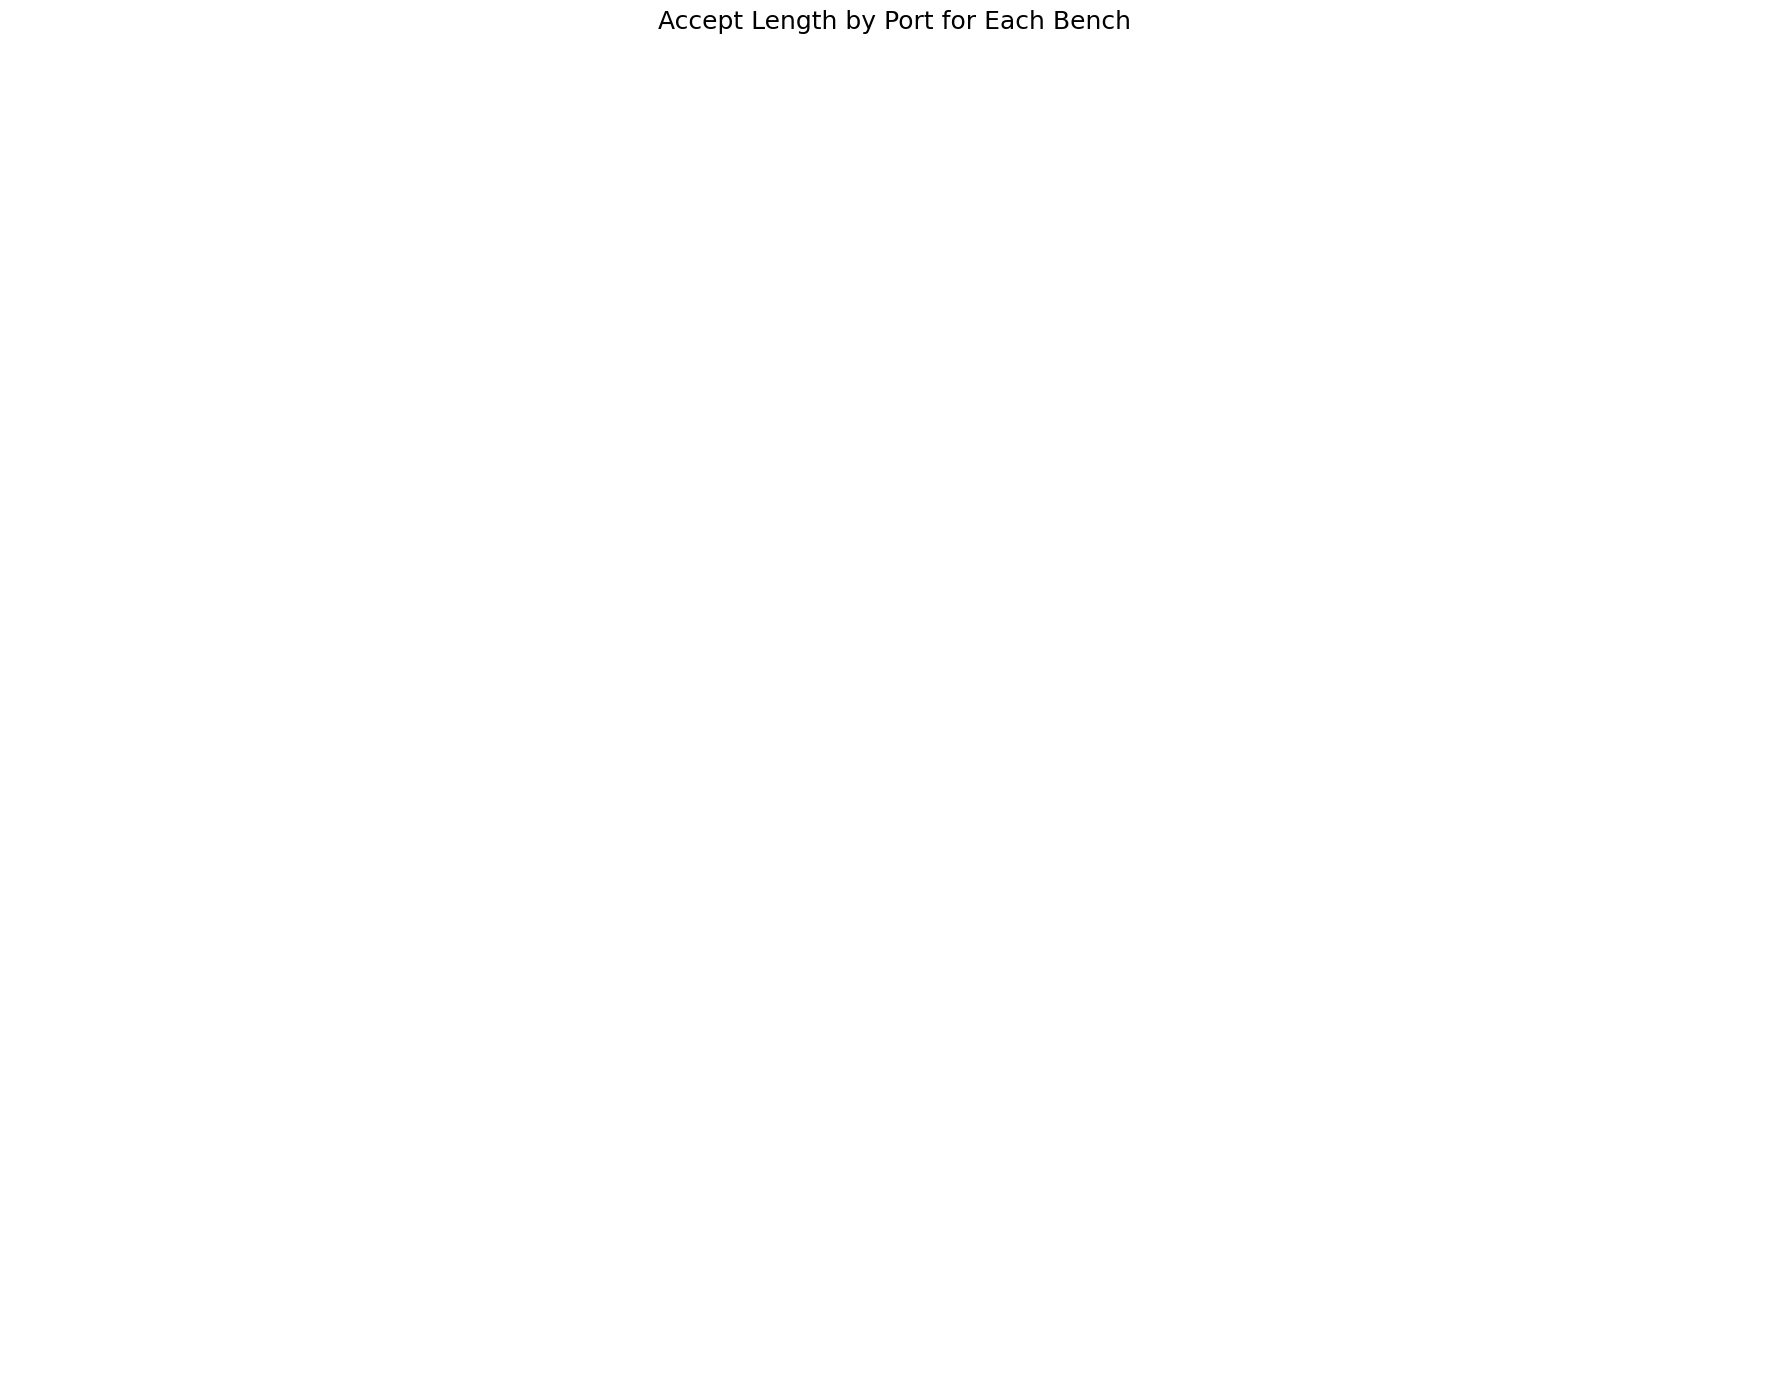

In [8]:
import json
import re
from pathlib import Path
import math
import matplotlib.pyplot as plt
from collections import defaultdict

log_path = Path("/mnt/shared-storage-user/leihaodi/diffusion/temp0.log")

eval_re = re.compile(r"^eval\s+(\S+)\s+temperature=([0-9.]+)")
port_re = re.compile(r"^port\s+(\d+)")
tokens_re = re.compile(r"Total completion_tokens:\s*(\d+)")

rows = []

current_bench = None
current_temperature = None
current_port = None

collecting_json = False
json_lines = []
brace_depth = 0
pending_obj = None

def brace_delta(s):
    # 这里 log 里的 JSON 比较简单，字符串里不会有花括号；因此直接计数即可
    return s.count("{") - s.count("}")

with log_path.open("r", encoding="utf-8") as f:
    for raw_line in f:
        line = raw_line.rstrip("\n")
        stripped = line.strip()

        # 如果刚解析完 JSON，但 Total completion_tokens 在下一行，也能处理
        token_match = tokens_re.search(line)
        if pending_obj is not None and token_match:
            metric = pending_obj.get("metrics", [{}])[0]
            config = pending_obj.get("config", {})

            rows.append({
                "bench": current_bench,
                "temperature": current_temperature,
                "port": config.get("port", current_port),
                "output_throughput": metric.get("output_throughput"),
                "accept_length": metric.get("accept_length"),
                "completion_tokens": int(token_match.group(1)),
            })

            pending_obj = None
            continue

        if collecting_json:
            token_match = tokens_re.search(line)

            # 处理 "}Total completion_tokens: 28321" 这种 JSON 结束和 token 粘在一起的情况
            json_part = line
            completion_tokens = None
            if token_match:
                completion_tokens = int(token_match.group(1))
                json_part = line.split("Total completion_tokens:", 1)[0]

            if json_part.strip():
                json_lines.append(json_part)
                brace_depth += brace_delta(json_part)

            if brace_depth == 0:
                obj = json.loads("\n".join(json_lines))

                if completion_tokens is None:
                    pending_obj = obj
                else:
                    metric = obj.get("metrics", [{}])[0]
                    config = obj.get("config", {})

                    rows.append({
                        "bench": current_bench,
                        "temperature": current_temperature,
                        "port": config.get("port", current_port),
                        "output_throughput": metric.get("output_throughput"),
                        "accept_length": metric.get("accept_length"),
                        "completion_tokens": completion_tokens,
                    })

                collecting_json = False
                json_lines = []
                brace_depth = 0

            continue

        m = eval_re.match(stripped)
        if m:
            current_bench = m.group(1)
            current_temperature = float(m.group(2))
            continue

        m = port_re.match(stripped)
        if m:
            current_port = int(m.group(1))
            continue

        # 只有顶层单独的 "{" 才开始收集 JSON
        if stripped == "{":
            collecting_json = True
            json_lines = [line]
            brace_depth = brace_delta(line)
            continue

last_bench = None

# rows 来自上一段解析代码
bench_to_rows = defaultdict(list)
for row in rows:
    bench_to_rows[row["bench"]].append(row)
bench_names = list(bench_to_rows.keys())
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for idx, bench in enumerate(bench_names[:7]):
    ax = axes[idx]
    bench_rows = bench_to_rows[bench]
    bench_rows = sorted(bench_rows, key=lambda x: x["port"])
    ports = [r["port"] for r in bench_rows]
    accept_lengths = [r["accept_length"] for r in bench_rows]
    ax.plot(
        ports,
        accept_lengths,
        marker="o",
        linewidth=2,
    )
    for port, accept_length in zip(ports, accept_lengths):
        ax.text(
            port,
            accept_length,
            f"{accept_length:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )
    ax.set_title(bench)
    ax.set_xlabel("port")
    ax.set_ylabel("accept_length")
    ax.set_xticks(ports)
    ax.grid(True, linestyle="--", alpha=0.4)
# 剩下的子图留空
for idx in range(len(bench_names[:7]), 9):
    axes[idx].axis("off")
fig.suptitle("Accept Length by Port for Each Bench", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
